In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load the Telangana market dataset

file_path = "C:/Users/vadde/OneDrive/Pictures/Desktop/TerraNexus/data/Telangana_Market_Report.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Dataset loaded successfully
Number of rows: 811
Number of columns: 1


,,,,,,,,"Market-wise, Commodity-wise Daily Report on: 19-Aug-2026"
Commodity,Arrivals,Unit of Arrivals,Variety,Grade,Minimum Price,Maximum Price,Modal Price,Unit of Price
State/UT Name : Telangana,nan,nan,nan,nan,nan,nan,nan,NaN
Market Name : APMC PATANCHERU,nan,nan,nan,nan,nan,nan,nan,NaN
Green Chilli,5.800000000000001,Metric Tonnes,Green Chilly,Local,3000.0,4000.0,3500.0,Rs./Quintal
Onion,49.300000000000004,Metric Tonnes,Onion,Local,2200.0,4200.0,3700.0,Rs./Quintal


In [4]:
# Inspect the raw structure of the file

with open("C:/Users/vadde/OneDrive/Pictures/Desktop/TerraNexus/data/Telangana_Market_Report.csv", "r", encoding="utf-8-sig", errors="replace") as file:
    for i in range(12):
        line = file.readline()
        print(f"Line {i+1}: {repr(line)}")

Line 1: '"Market-wise, Commodity-wise Daily Report on: 19-Aug-2026"\n'
Line 2: '\n'
Line 3: 'Commodity,Arrivals,Unit of Arrivals,Variety,Grade,Minimum Price,Maximum Price,Modal Price,Unit of Price\n'
Line 4: 'State/UT Name : Telangana\n'
Line 5: 'Market Name : APMC PATANCHERU\n'
Line 6: 'Green Chilli,5.800000000000001,Metric Tonnes,Green Chilly,Local,3000.0,4000.0,3500.0,Rs./Quintal\n'
Line 7: 'Onion,49.300000000000004,Metric Tonnes,Onion,Local,2200.0,4200.0,3700.0,Rs./Quintal\n'
Line 8: 'Potato,40.0,Metric Tonnes,Potato,Local,1100.0,1300.0,1200.0,Rs./Quintal\n'
Line 9: 'Tomato,42.900000000000006,Metric Tonnes,Tomato,Local,600.0,1000.0,800.0,Rs./Quintal\n'
Line 10: 'Market Name : Achampet APMC\n'
Line 11: 'NIL Transaction - No Arrivals\n'
Line 12: 'Market Name : Adilabad (Rythu Bazar) \n'


In [5]:
import csv
import pandas as pd

# Read the raw report and extract valid commodity records
records = []
current_market = None

with open("C:/Users/vadde/OneDrive/Pictures/Desktop/TerraNexus/data/Telangana_Market_Report.csv", "r", encoding="utf-8-sig", errors="replace", newline="") as file:
    reader = csv.reader(file)

    for row in reader:
        # Remove extra spaces
        row = [item.strip() for item in row]

        # Identify the market name
        if len(row) == 1 and row[0].startswith("Market Name :"):
            current_market = row[0].replace("Market Name :", "").strip()

        # Keep only actual commodity records
        elif len(row) == 9 and current_market:
            commodity = row[0]

            # Ignore non-data rows
            if commodity and not commodity.startswith("NIL"):
                records.append([
                    current_market,
                    row[0],
                    row[1],
                    row[2],
                    row[3],
                    row[4],
                    row[5],
                    row[6],
                    row[7],
                    row[8]
                ])

# Create a clean DataFrame
columns = [
    "Market",
    "Commodity",
    "Arrivals",
    "Unit of Arrivals",
    "Variety",
    "Grade",
    "Minimum Price",
    "Maximum Price",
    "Modal Price",
    "Unit of Price"
]

df = pd.DataFrame(records, columns=columns)

print("Clean dataset created successfully")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head(10))

Clean dataset created successfully
Number of rows: 461
Number of columns: 10


,Market,Commodity,Arrivals,Unit of Arrivals,Variety,Grade,Minimum Price,Maximum Price,Modal Price,Unit of Price
0,APMC PATANCHERU,Green Chilli,5.800000000000001,Metric Tonnes,Green Chilly,Local,3000.0,4000.0,3500.0,Rs./Quintal
1,APMC PATANCHERU,Onion,49.300000000000004,Metric Tonnes,Onion,Local,2200.0,4200.0,3700.0,Rs./Quintal
2,APMC PATANCHERU,Potato,40.0,Metric Tonnes,Potato,Local,1100.0,1300.0,1200.0,Rs./Quintal
3,APMC PATANCHERU,Tomato,42.900000000000006,Metric Tonnes,Tomato,Local,600.0,1000.0,800.0,Rs./Quintal
4,Adilabad (Rythu Bazar),Bhindi(Ladies Finger),2.6,Metric Tonnes,Bhindi,Local,2000.0,5200.0,2000.0,Rs./Quintal
5,Adilabad (Rythu Bazar),Brinjal,1.4000000000000001,Metric Tonnes,Brinjal,Local,3000.0,8200.0,3000.0,Rs./Quintal
6,Adilabad (Rythu Bazar),Cabbage,1.9000000000000001,Metric Tonnes,Cabbage,Local,2000.0,5200.0,2000.0,Rs./Quintal
7,Adilabad (Rythu Bazar),Cauliflower,0.8,Metric Tonnes,Cauliflower,Local,3000.0,8200.0,3000.0,Rs./Quintal
8,Adilabad (Rythu Bazar),Green Chilli,1.8,Metric Tonnes,Green Chilly,Local,8000.0,8200.0,8000.0,Rs./Quintal
9,Adilabad (Rythu Bazar),Tomato,4.1000000000000005,Metric Tonnes,Local,Local,2000.0,3000.0,2000.0,Rs./Quintal


In [8]:
# STEP 5: Data Quality Check

print("DATASET INFORMATION")
print("-" * 40)

print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nBasic Statistics:")
display(df.describe())

DATASET INFORMATION
----------------------------------------
Shape: (461, 10)

Data Types:
Market              str
Commodity           str
Arrivals            str
Unit of Arrivals    str
Variety             str
Grade               str
Minimum Price       str
Maximum Price       str
Modal Price         str
Unit of Price       str
dtype: object

Missing Values:
Market              0
Commodity           0
Arrivals            0
Unit of Arrivals    0
Variety             0
Grade               0
Minimum Price       0
Maximum Price       0
Modal Price         0
Unit of Price       0
dtype: int64

Duplicate Rows:
0

Basic Statistics:


,Market,Commodity,Arrivals,Unit of Arrivals,Variety,Grade,Minimum Price,Maximum Price,Modal Price,Unit of Price
count,461,461,461,461,461,461,461,461,461,461
unique,64,88,242,3,109,10,123,139,145,3
top,Bowenpally APMC,Tomato,0.2,Metric Tonnes,Other,Grade A,3500.0,3000.0,3500.0,Rs./Quintal
freq,36,26,15,453,44,126,32,41,31,453


In [6]:
# STEP 6: Convert numerical columns to numeric data types

numeric_columns = [
    "Arrivals",
    "Minimum Price",
    "Maximum Price",
    "Modal Price"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print("Numeric conversion completed successfully")

print("\nUpdated Data Types:")
print(df.dtypes)

print("\nMissing Values After Conversion:")
print(df[numeric_columns].isnull().sum())

Numeric conversion completed successfully

Updated Data Types:
Market                  str
Commodity               str
Arrivals            float64
Unit of Arrivals        str
Variety                 str
Grade                   str
Minimum Price       float64
Maximum Price       float64
Modal Price         float64
Unit of Price           str
dtype: object

Missing Values After Conversion:
Arrivals         0
Minimum Price    0
Maximum Price    0
Modal Price      0
dtype: int64


In [7]:
# STEP 7: Define features and target

target = "Modal Price"

features = [
    "Market",
    "Commodity",
    "Arrivals",
    "Variety",
    "Grade",
    "Minimum Price",
    "Maximum Price"
]

X = df[features].copy()
y = df[target].copy()

print("Features and target prepared successfully")
print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features and target prepared successfully

Features:
['Market', 'Commodity', 'Arrivals', 'Variety', 'Grade', 'Minimum Price', 'Maximum Price']

Target:
Modal Price

Feature shape: (461, 7)
Target shape: (461,)


In [8]:
# STEP 8: Prepare data for machine learning

categorical_features = [
    "Market",
    "Commodity",
    "Variety",
    "Grade"
]

numerical_features = [
    "Arrivals"
]

all_features = categorical_features + numerical_features

X = df[all_features].copy()
y = df["Modal Price"].copy()

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Data split completed successfully")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Data split completed successfully
Training samples: 368
Testing samples: 93
Number of features: 5


In [9]:
# STEP 9: Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully")

Preprocessing pipeline created successfully


In [10]:
# STEP 10: Train machine learning models

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    print(f"{name} trained successfully")

print("\nAll models trained successfully!")

Linear Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully

All models trained successfully!


In [11]:
# STEP 11: Evaluate model performance

results = []

for name, model in trained_models.items():
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = mean_squared_error(y_test, predictions) ** 0.5
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

print("Model evaluation completed successfully")
display(results_df)

Model evaluation completed successfully


,Model,MAE,RMSE,R2 Score
0,Linear Regression,2687.010557,8986.399884,-0.170596
1,Decision Tree,2256.716851,7955.556310,0.082562
2,Random Forest,2041.378248,7738.772410,0.131880


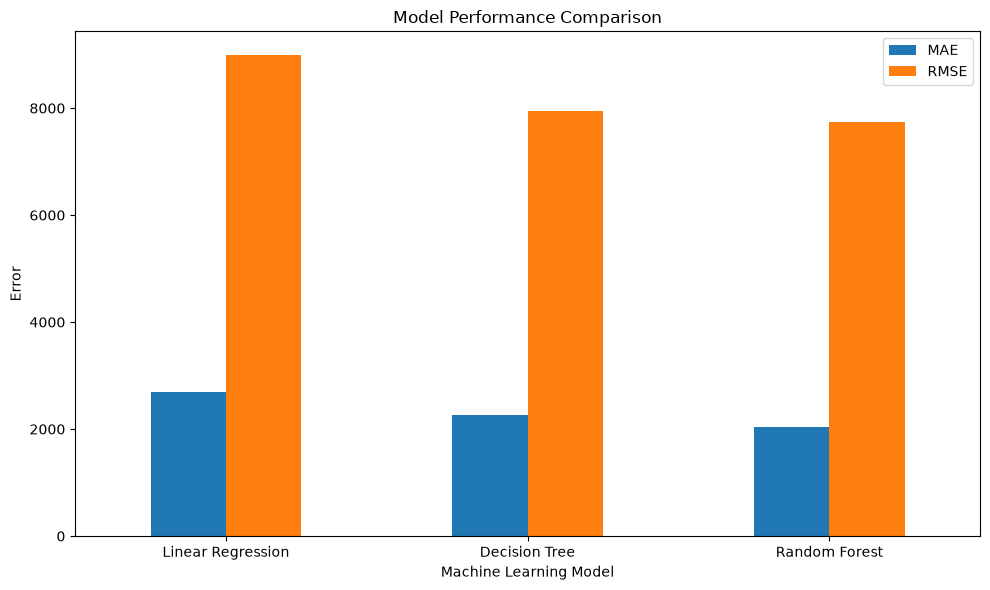

In [12]:
# STEP 12: Compare model performance

results_df.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.xlabel("Machine Learning Model")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../results/model_performance_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

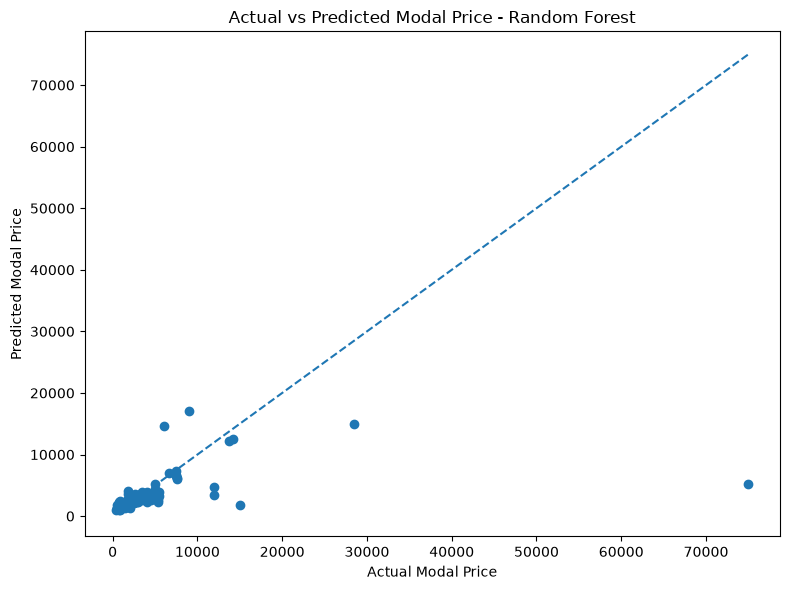

In [13]:
# STEP 13: Actual vs Predicted Price

best_model = trained_models["Random Forest"]

rf_predictions = best_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Modal Price")
plt.ylabel("Predicted Modal Price")
plt.title("Actual vs Predicted Modal Price - Random Forest")

# Reference line
min_value = min(y_test.min(), rf_predictions.min())
max_value = max(y_test.max(), rf_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()

plt.savefig(
    "../results/actual_vs_predicted_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# STEP 14: Analyze average modal price by commodity

commodity_price = (
    df.groupby("Commodity")["Modal Price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 commodities by average Modal Price:")

display(commodity_price)

Top 10 commodities by average Modal Price:


Commodity
Kankambra       120000.0
Blueberry        75000.0
Kakada           50000.0
Jasmine          42000.0
Lilly            20000.0
Litchi           18750.0
Carnation        18000.0
Dry Chillies     17625.0
Avocado          17500.0
Kiwi Fruit       16000.0
Name: Modal Price, dtype: float64

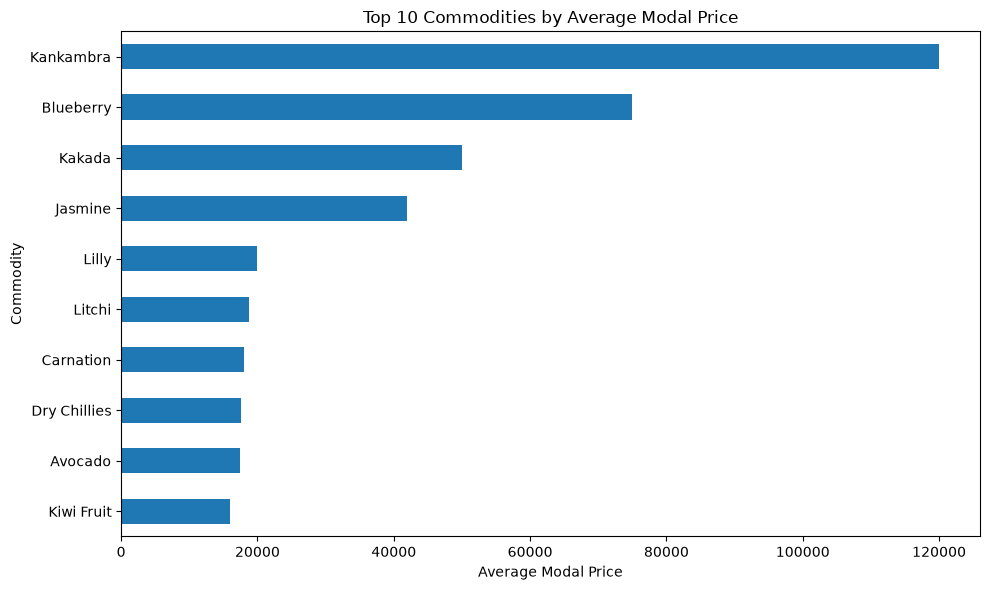

In [15]:
# STEP 15: Visualize top commodities by average Modal Price

plt.figure(figsize=(10, 6))

commodity_price.sort_values().plot(kind="barh")

plt.title("Top 10 Commodities by Average Modal Price")
plt.xlabel("Average Modal Price")
plt.ylabel("Commodity")

plt.tight_layout()
plt.show()

In [16]:
# STEP 16: Check number of records for top commodities

top_commodities = commodity_price.index

commodity_counts = (
    df[df["Commodity"].isin(top_commodities)]
    .groupby("Commodity")
    .size()
    .sort_values(ascending=False)
)

print("Number of records for the top 10 commodities:")

display(commodity_counts)

Number of records for the top 10 commodities:


Commodity
Dry Chillies    8
Avocado         1
Blueberry       1
Carnation       1
Jasmine         1
Kakada          1
Kankambra       1
Kiwi Fruit      1
Lilly           1
Litchi          1
dtype: int64

In [17]:
# STEP 17: Save model evaluation results

results_path = "../results/model_results.csv"

results_df.to_csv(results_path, index=False)

print("Model results saved successfully")
print("Saved to:", results_path)

Model results saved successfully
Saved to: ../results/model_results.csv


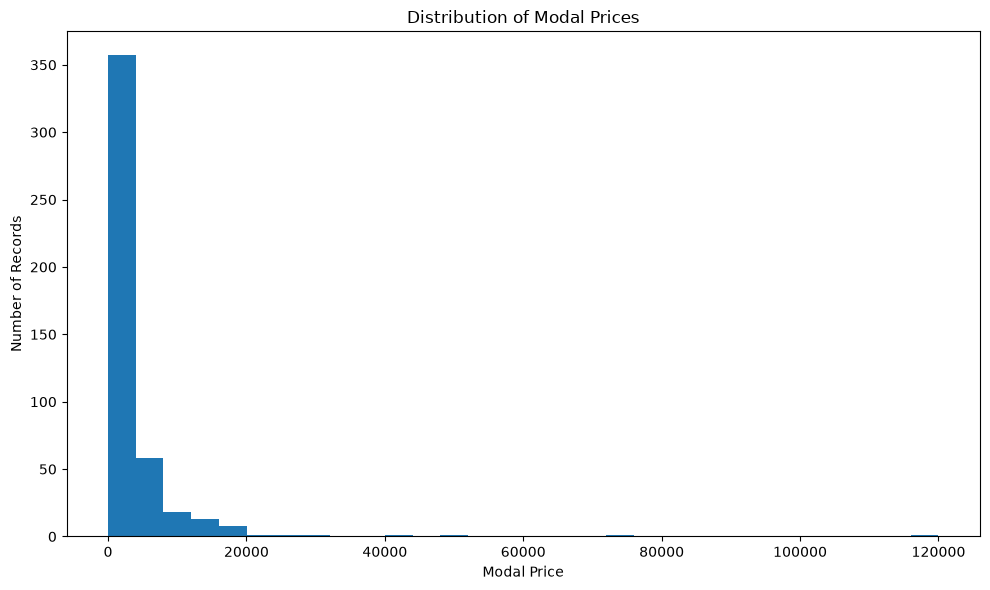

In [ ]:
# STEP 18: Analyze Modal Price Distribution

plt.figure(figsize=(10, 6))

plt.hist(df["Modal Price"], bins=30)

plt.title("Distribution of Modal Prices")
plt.xlabel("Modal Price")
plt.ylabel("Number of Records")

plt.tight_layout()

plt.savefig(
    "../results/modal_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()